# Task 1 : Set up colab gpu runtime environment

In [1]:
!pip install segmentation-models-pytorch
!pip install -U git+https://github.com/albumentations-team/albumentations
!pip install --upgrade opencv-contrib-python

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable
  Cloning https://github.com/albumentations-team/albumentations to /tmp/pip-req-build-39h0as1m
  Running command git clone --filter=blob:none --quiet https://github.com/albumentations-team/albumentations /tmp/pip-req-build-39h0as1m
  Resolved https://github.com/albumentations-team/albumentations to commit ef505c6d8074693471c67fbb761187bc0ab58dd1
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.3.1 -> 25

# About Dataset

### Dataset
Dataset used in:

Mateusz Buda, AshirbaniSaha, Maciej A. Mazurowski "Association of genomic subtypes of lower-grade gliomas with shape features automatically extracted by a deep learning algorithm." Computers in Biology and Medicine, 2019.

link : https://www.kaggle.com/datasets/mateuszbuda/lgg-mri-segmentation


# Some Common Imports

In [2]:
import torch
import cv2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tqdm import tqdm

import helper

# Task : 2 Setup Configurations

In [3]:
CSV_FILE = 'dataset.csv'
DATA_DIR = 'data/MRI_kaggle/kaggle_3m'
DEVICE = 'cuda'
EPOCH = 25
LR = 1e-4
BATCH_SIZE = 8
IMG_SIZE = 512

ENCODER = 'timm-efficientnet-b0'
WEIGHTS = 'imagenet'

In [4]:
CSV_FILE

'dataset.csv'

In [5]:
import torch

if torch.cuda.is_available():
    print("CUDA is available. You are using a GPU.")
else:
    print("CUDA is not available. Using CPU.")


CUDA is available. You are using a GPU.


In [6]:
df = pd.read_csv(CSV_FILE) 

print(df.head())
#ssconvert  for gnumeric type to csv 
#ssconvert dataset.csv dataset.csv

                         images                              masks
0   TCGA_CS_4941_19960909_1.tif  TCGA_CS_4941_19960909_10_mask.tif
1  TCGA_CS_4941_19960909_10.tif  TCGA_CS_4941_19960909_11_mask.tif
2  TCGA_CS_4941_19960909_11.tif  TCGA_CS_4941_19960909_12_mask.tif
3  TCGA_CS_4941_19960909_12.tif  TCGA_CS_4941_19960909_13_mask.tif
4  TCGA_CS_4941_19960909_13.tif  TCGA_CS_4941_19960909_14_mask.tif


In [7]:
idx = 3
image_path = DATA_DIR +'/images/'+ df['images'].iloc[idx]
print(image_path)
mask_path = DATA_DIR +'/masks/'+ df['masks'].iloc[idx]
image = cv2.imread(image_path,cv2.IMREAD_COLOR)
mask = cv2.imread(mask_path,cv2.IMREAD_GRAYSCALE)

data/MRI_kaggle/kaggle_3m/images/TCGA_CS_4941_19960909_12.tif


In [8]:
import os

print(os.path.exists("data/MRI_kaggle/kaggle_3m/images/TCGA_CS_4941_19960909_1.tiff"))

False


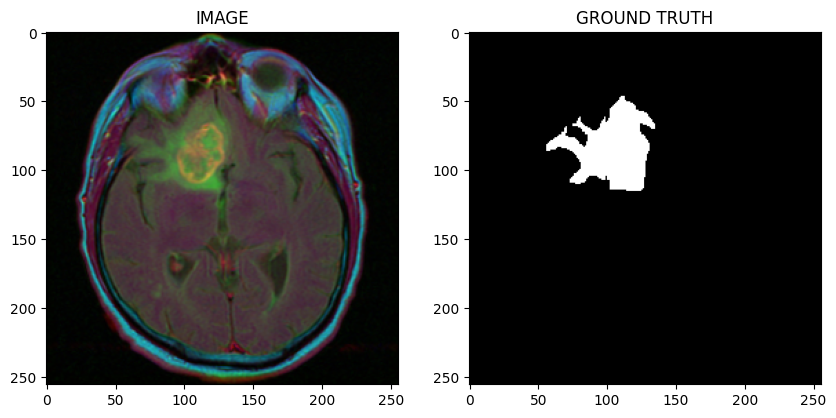

In [9]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

ax1.set_title('IMAGE')
ax1.imshow(image)

ax2.set_title('GROUND TRUTH')
ax2.imshow(mask,cmap = 'gray')

In [10]:
train_df,val_df = train_test_split(df,test_size = 0.2, random_state= 42)
len(train_df)


3143

In [11]:
print(train_df.size)

6286


In [12]:
len(val_df)

786

# Task 3 : Augmentation Functions

albumentation documentation : https://albumentations.ai/docs/

In [13]:
import albumentations as A

In [14]:
def get_train_augs():
  return A.Compose([
      A.Resize(IMG_SIZE,IMG_SIZE),
      A.HorizontalFlip(p=.5),
      A.VerticalFlip(p= 0.5)
  ])
def get_valid_augs():
  return A.Compose([
      A.Resize(IMG_SIZE,IMG_SIZE)
  ])

# Task 4 : Create Custom Dataset

In [15]:
from torch.utils.data import Dataset


In [16]:
class SegmentationData(Dataset):
  def __init__(self,df,augmentations):
    self.df =df
    self.augmentations = augmentations
  def __len__(self):
    return len(self.df)

  def __getitem__(self,idx):
    row = df.iloc[idx]
    image_path = DATA_DIR +'/images/'+ row.images
    mask_path = DATA_DIR + '/masks/'+row.masks
    image = cv2.imread(image_path,cv2.IMREAD_COLOR) #(h,w,c)
    mask = cv2.imread(mask_path,cv2.IMREAD_GRAYSCALE) #(h,w)
    mask = np.expand_dims(mask,axis= -1) #(h,w,c)
    #print(mask.shape)

    if self.augmentations:
      data = self.augmentations(image = image, mask = mask) #return a dictionary
      image = data['image']
      mask = data['mask']
      #print(mask.shape)

    image = np.transpose(image,(2,0,1)).astype(np.float32) #(channel,h,w)
    mask =  np.transpose(mask,(2,0,1)).astype(np.float32) #(channel,h,w)
    image = torch.tensor(image)/255 #making the float to 0 to 1
    mask = torch.round(torch.tensor(mask)/255) #making the float to 0 to 1
    return image,mask

In [17]:
train_dataset = SegmentationData(train_df,get_train_augs())
valid_dataset = SegmentationData(val_df,get_valid_augs())

In [18]:
len(train_dataset)

3143

In [19]:
idx = 3
image,mask = train_dataset[idx]

In [20]:
mask.shape

torch.Size([1, 512, 512])

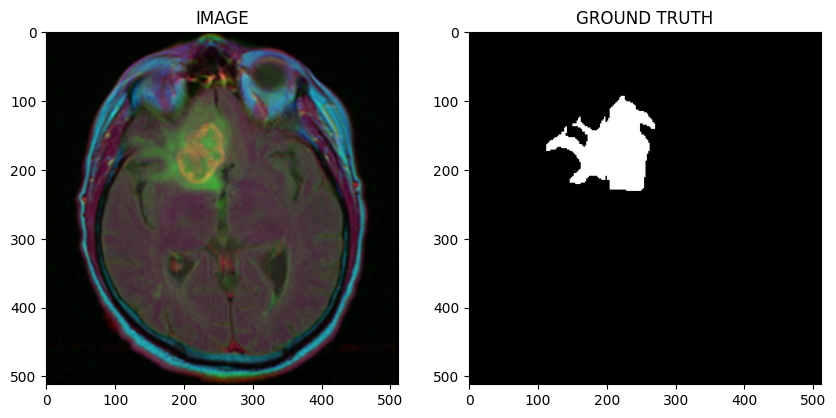

In [21]:
helper.show_image(image,mask)

# Task 5 : Load dataset into batches

In [22]:
from torch.utils.data import DataLoader

In [23]:
train_loader = DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True)
valid_loader = DataLoader(valid_dataset,batch_size= BATCH_SIZE)


In [24]:
print(f'Total number of images in train set : {len(train_dataset)}')
print(f'Total number of images in validation set : {len(valid_dataset)}')

Total number of images in train set : 3143
Total number of images in validation set : 786


In [25]:
print(f'Total number of batches in train loader : {len(train_loader)}')
print(f'Total number of batches in validation loader : {len(valid_loader)}')

Total number of batches in train loader : 393
Total number of batches in validation loader : 99


In [26]:
for images,mask in train_loader:
  print(images.shape)
  print(mask.shape)
  break

torch.Size([8, 3, 512, 512])
torch.Size([8, 1, 512, 512])


In [27]:
for images,mask in valid_loader:
  print(images.shape)
  print(mask.shape)
  break

torch.Size([8, 3, 512, 512])
torch.Size([8, 1, 512, 512])


# Task 6 : Create Segmentation Model

segmentation_models_pytorch documentation : https://smp.readthedocs.io/en/latest/

In [28]:

import segmentation_models_pytorch as smp
from segmentation_models_pytorch.losses import DiceLoss

from torch import nn


In [29]:
class SegmentationModel(nn.Module):
  def __init__(self):
    super(SegmentationModel,self).__init__()
    self.backbone = smp.Unet(
        encoder_name = ENCODER,
        encoder_weights = WEIGHTS,
        in_channels = 3,
        classes = 1,
        activation = None
    )
  def forward(self,images,masks = None):
    logits = self.backbone(images)
    if masks is not  None:
      return logits, DiceLoss(mode = 'binary')(logits,masks)+nn.BCEWithLogitsLoss()(logits,masks)

    return logits

In [30]:
model = SegmentationModel().to(DEVICE)

# Task 7 : Create Train and Validation Function

In [53]:

from torch.amp import autocast, GradScaler
# Initialize GradScaler
scaler = GradScaler()

def train_fn(train_loader, model, optimizer):
    model.train()
    total_loss = 0
    for images, masks in tqdm(train_loader):
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)
        
        optimizer.zero_grad()

        # Using autocast to automatically use mixed precision during the forward pass
        with autocast(device_type="cuda", dtype=torch.float16):
            logits,loss= model(images, masks)
        
        # Scale the loss and backpropagate with GradScaler
        scaler.scale(loss).backward()

        # Unscale gradients and apply the optimizer
        scaler.step(optimizer)
        
        # Update the scale for next iteration
        scaler.update()
        
        total_loss += loss.item()

    return total_loss / len(train_loader)


In [38]:
from sklearn.metrics import f1_score, jaccard_score, precision_score, recall_score
from scipy.spatial.distance import directed_hausdorff

In [47]:
OUTPUT_DIR = "OUTPUTs"
os.makedirs(OUTPUT_DIR, exist_ok=True)



def eval_fn(data_loader, model):
    model.eval()  # to turn on the dropout, batchnorm, etc.
    total_loss = 0
    with torch.no_grad():
        for images, masks in tqdm(data_loader):
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)
            
            # Use autocast to reduce memory usage during the forward pass
            with autocast(device_type="cuda", dtype=torch.float16):
                logits,loss = model(images, masks)
               
            total_loss += loss.item()
    
    return total_loss / len(data_loader)


In [54]:
def compute_metrics(true_mask, pred_mask):
    # Compute Dice score, IoU, Recall (you can add Precision if needed)
    intersection = np.sum(true_mask * pred_mask)
    union = np.sum(true_mask) + np.sum(pred_mask)
    true_positive = intersection
    false_positive = np.sum(pred_mask) - true_positive
    false_negative = np.sum(true_mask) - true_positive

    dice_score = 2 * intersection / (np.sum(true_mask) + np.sum(pred_mask))
    iou = intersection / union
    recall = true_positive / (true_positive + false_negative) if (true_positive + false_negative) > 0 else 0

    return dice_score, iou, recall

def hausdorff_distance(true_mask, pred_mask):
    # Hausdorff distance implementation (use an appropriate library or implement it)
    # You can use libraries like `scipy` for Hausdorff distance calculation
    from scipy.spatial.distance import directed_hausdorff

    def hausdorff_2d(A, B):
        # Compute directed Hausdorff distance between two binary images
        d1 = directed_hausdorff(A, B)[0]
        d2 = directed_hausdorff(B, A)[0]
        return max(d1, d2)

    return hausdorff_2d(true_mask, pred_mask)

def eval_fn(data_loader, model, epoch):
    model.eval()
    total_loss = 0
    results = []

    with torch.no_grad():
        for idx, (images, masks) in enumerate(tqdm(data_loader)):
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            with autocast("cuda", dtype=torch.float16):
                logits, loss = model(images, masks)
            
            total_loss += loss.item()

            # Convert logits to binary mask predictions
            preds = torch.sigmoid(logits)
            preds_bin = (preds > 0.5).float()  # Apply threshold to logits

            # Convert tensors to NumPy arrays (for use in metric calculations)
            masks_np = masks.cpu().numpy().astype(np.uint8)[0, 0, :, :]
            preds_np = preds_bin.cpu().numpy().astype(np.uint8)[0, 0, :, :]

            # Compute metrics
            dice, iou, recall = compute_metrics(masks_np, preds_np)
            hausdorff = hausdorff_distance(masks_np, preds_np)

            # Save masks to output folder
            target_path = os.path.join(OUTPUT_DIR, f"epoch_{epoch}_image_{idx}_target.png")
            pred_path = os.path.join(OUTPUT_DIR, f"epoch_{epoch}_image_{idx}_pred.png")

            cv2.imwrite(target_path, masks_np * 255)  # Save ground truth mask
            cv2.imwrite(pred_path, preds_np * 255)  # Save predicted mask

            # Append results for CSV
            results.append([f"image_{idx}", dice, iou, recall, hausdorff])

    # Save results as CSV file after each epoch
    df = pd.DataFrame(results, columns=["Image", "Dice Score", "IoU", "Recall", "Hausdorff Distance"])
    df.to_csv(os.path.join(OUTPUT_DIR, f"epoch_{epoch}_results.csv"), index=False)

    avg_loss = total_loss / len(data_loader)
    print(f"Validation Loss for Epoch {epoch}: {avg_loss:.4f}")

    return avg_loss

In [55]:
optimizer = torch.optim.Adam(model.parameters(),lr=LR)

In [56]:
best_loss = np.inf  # Initialize with a high loss value
best_dice = -np.inf  # Initialize with a low Dice score

for epoch in range(EPOCH):
    train_loss = train_fn(train_loader, model, optimizer)
    valid_loss = eval_fn(valid_loader, model, epoch)
    
    # Save the model if validation loss improves
    if valid_loss < best_loss:
        best_loss = valid_loss
        torch.save({
            'model_state_dict': model.state_dict(),
        }, 'best_model.pth')
        
        # Save the predicted masks for the best epoch
        print(f"Saving predicted masks for best model at epoch {epoch+1} with loss: {best_loss}")
        
        # Save predicted masks for the best model at this epoch
        with torch.no_grad():
            model.eval()
            for idx, (images, masks) in enumerate(tqdm(valid_loader)):
                images = images.to(DEVICE)
                masks = masks.to(DEVICE)

                # Use autocast for mixed precision
                with autocast(device_type="cuda", dtype=torch.float16):
                    logits = model(images)
                # Clear unused memory
                torch.cuda.empty_cache()
                # Convert logits to binary mask predictions
                preds = torch.sigmoid(logits)
                preds_bin = (preds > 0.5).float()

                # Convert tensors to NumPy arrays (you may want to remove the [0, 0, :, :] indexing)
                # Remove [0, 0, :, :] indexing for flexibility
                masks_np = masks.cpu().numpy().astype(np.uint8)
                preds_np = preds_bin.cpu().numpy().astype(np.uint8)

                # If your batch size > 1, you need to iterate over the batch
                for b in range(masks_np.shape[0]):  # Iterate over each image in the batch
                    target_path = os.path.join(OUTPUT_DIR, f"best_model_epoch_{epoch+1}_image_{idx * masks_np.shape[0] + b}_target.png")
                    pred_path = os.path.join(OUTPUT_DIR, f"best_model_epoch_{epoch+1}_image_{idx * masks_np.shape[0] + b}_pred.png")

                    # Save ground truth mask and predicted mask
                    cv2.imwrite(target_path, masks_np[b, 0, :, :] * 255)  # Save ground truth mask (first channel)
                    cv2.imwrite(pred_path, preds_np[b, 0, :, :] * 255)  # Save predicted mask (first channel)

    print(f'Epoch: {epoch+1}, Train Loss: {train_loss}, Valid Loss: {valid_loss}')


  0%|          | 0/99 [00:00<?, ?it/s]/tmp/ipykernel_4951/251063406.py:9: RuntimeWarning: invalid value encountered in scalar divide
  dice_score = 2 * intersection / (np.sum(true_mask) + np.sum(pred_mask))
/tmp/ipykernel_4951/251063406.py:10: RuntimeWarning: invalid value encountered in scalar divide
  iou = intersection / union
100%|██████████| 99/99 [00:27<00:00,  3.66it/s]


Validation Loss for Epoch 0: 0.3390
Saving predicted masks for best model at epoch 1 with loss: 0.33904454792200617


100%|██████████| 99/99 [00:11<00:00,  8.45it/s]


Epoch: 1, Train Loss: 0.5302356318701011, Valid Loss: 0.33904454792200617


100%|██████████| 99/99 [00:27<00:00,  3.67it/s]


...

Validation Loss for Epoch 23: 0.2434
Epoch: 24, Train Loss: 0.28432773153273944, Valid Loss: 0.24342365685675998


100%|██████████| 99/99 [00:27<00:00,  3.56it/s]


Validation Loss for Epoch 24: 0.2381
Saving predicted masks for best model at epoch 25 with loss: 0.23805671872500023


100%|██████████| 99/99 [00:12<00:00,  7.84it/s]

Epoch: 25, Train Loss: 0.27249703716193935, Valid Loss: 0.23805671872500023


In [60]:
print(train_loss)

0.27249703716193935


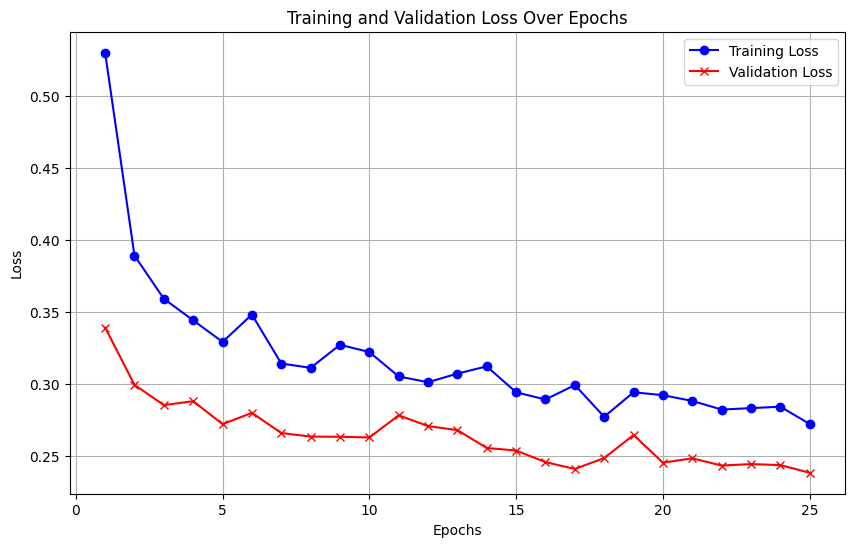

In [63]:
import matplotlib.pyplot as plt

# Assuming you have lists of train_losses and val_losses
train_losses = [0.530, 0.389, 0.359, 0.344, 0.329, 0.348, 0.314, 0.311, 0.327, 0.322, 0.305, 0.301, 0.307, 0.312, 0.294, 0.289, 0.299, 0.277, 0.294, 0.292, 0.288, 0.282, 0.283, 0.284, 0.272]  # Replace with actual values
val_losses = [0.3390, 0.2992, 0.2851, 0.2878, 0.2719, 0.2797, 0.2657, 0.2632, 0.2631, 0.2626, 0.2780, 0.2705, 0.2677, 0.2553, 0.2535, 0.2455, 0.2407, 0.2483, 0.2643, 0.2451, 0.2481, 0.2431, 0.2441, 0.2434, 0.2381]  # Replace with actual values

epochs = list(range(1, len(train_losses) + 1))

# Plotting the training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_losses, label='Training Loss', color='blue', linestyle='-', marker='o')
plt.plot(epochs, val_losses, label='Validation Loss', color='red', linestyle='-', marker='x')

# Adding labels and title
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()

# Display the plot
plt.grid(True)
plt.savefig("traing_validation_loss.png")
plt.show()


# Task 8 : Train Model

# Task 9 : Inference

In [85]:
idx = 7

checkpoint = torch.load('model_for_MRI_image.pth')
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
image,mask = valid_dataset[idx]
logits_mask = model(image.to(DEVICE).unsqueeze(0)) #logits are the raw output without sigmoid or activation function , so the model ouput is (c,h,w ) but fpr prediction it needs batch. that's wht the squeex, it will add a extra dimension for batch
pred_mask = torch.sigmoid(logits_mask)
pred_mask = (pred_mask > 0.5)*1.0  #making 0 and 1 for binary segmentation
pred_mask = pred_mask.detach().cpu().squeeze(0) # so for printing the predicted image we need to remove the batch.


In [64]:
checkpoint = torch.load('best_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

In [59]:
print(checkpoint)

{'model_state_dict': OrderedDict([('backbone.encoder.conv_stem.weight', tensor([[[[-4.3723e-01, -2.9492e-01,  2.1299e-02],
          [-1.5690e-01, -1.7705e-01,  1.3974e-02],
          [ 8.4538e-02,  5.3353e-02, -1.6770e-02]],

         [[-4.6155e-01, -3.4492e-01, -1.1555e-01],
          [-2.4909e-01, -3.1581e-01, -1.2203e-01],
          [-2.8153e-03, -6.7805e-02, -4.3079e-02]],

         [[-2.1141e-01, -1.6053e-01,  1.0585e-01],
          [ 2.1445e-02, -1.2188e-01,  7.4565e-02],
          [ 6.3828e-02, -2.0168e-02,  4.4183e-02]]],


        [[[-3.2812e-02, -3.4930e-02,  6.3877e-02],
          [-1.8243e-02,  3.6637e-03,  2.2903e-02],
          [ 5.4500e-02,  5.5720e-01, -3.4107e-02]],

         [[ 8.8619e-02, -2.2527e-02,  2.4653e-02],
          [ 3.0733e-02, -1.8119e-02,  1.4881e-02],
          [ 1.6989e-01,  8.0289e-01,  1.1276e-01]],

         [[-3.5006e-02, -7.7138e-03, -8.4435e-02],
          [-1.0657e-02,  1.9312e-01,  1.0667e-02],
          [-2.4320e-01,  6.7239e-01, -5.7747e-02]

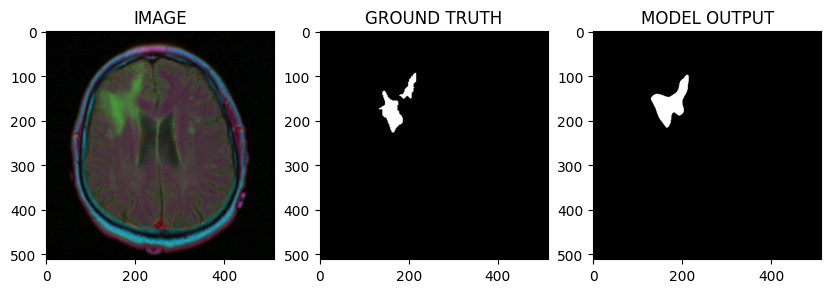

In [59]:
helper.show_image(image,mask,pred_mask)